In [85]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [86]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"social_ads.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


## 1. 데이터 전처리

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [88]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [89]:
ads_df = df.drop("User ID", axis=1)
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [90]:
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

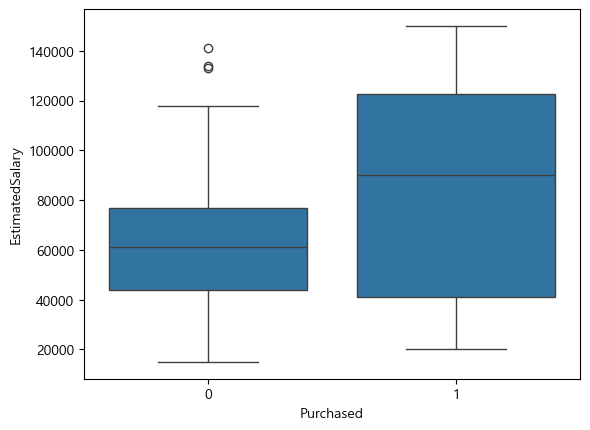

In [91]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

In [103]:
# 둘다 동일하게 사용된다

# ads_df["Gender"] = ads_df["Gender"].map({"Male": 0, "Female": 1})
# ads_df = pd.get_dummies(ads_df, columns=["Gender"], dtype=int, drop_first=True)

In [93]:
X = ads_df.drop("Purchased", axis=1)
X.head()

,Age,EstimatedSalary,Gender_Male
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


In [94]:
y = ads_df["Purchased"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [95]:
X.columns = ["Age", "Salary", "Gender"]
X.head()

,Age,Salary,Gender
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


## 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유 -> 데이터 셋을 나누기 전에 전체 데이터를 스케일링하면 모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 스며들어서 데이터 누수가 발생한다.

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 3) (80, 3) (320,) (80,)


In [97]:
# 1. 자르고 표준화 진행
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. 모델 준비

In [98]:
# Salary 연봉
X_train_salary = X_train_scaled[:, [1]]
X_test_salary = X_test_scaled[:, [1]]

In [99]:
# 선형회귀 모델(weight * x) + bias
# weight: 가중치
# bias: 절편
lr = LinearRegression()

In [100]:
lr.fit(X_train_salary, y_train)

LinearRegression()

In [101]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620512


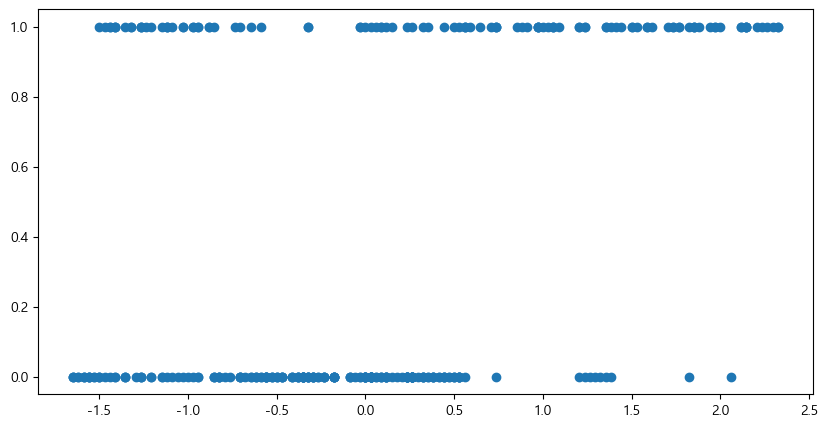

In [105]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train_salary, y_train)
plt.plot(0, 1, 1)
plt.show()

## 쓰레기 모델이기에 다른 모델 준비

In [106]:
lr = LogisticRegression()

## 모델 학습

In [107]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

## 모델 예측

In [109]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0], dtype=int64)

## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

## 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화되는 현상을 의미한다.
- 현재 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 때 예측능력이 크게 떨어질 수 있다.
- 이런 현상을 과적합이라고 한다.

In [112]:
print(f"훈련 데이터 점수: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 데이터 점수: {accuracy_score(y_test, y_pred)}")

훈련 데이터 점수: 0.853125
테스트 데이터 점수: 0.7875


In [124]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df
# lr.coef_[0] # 각 컬럼마다의 가중치

,Features,Coef
0,Age,2.394875
1,Salary,1.161530
2,Gender,0.373889


In [ ]:
"""
    소셜에서 상품을 구매할 때에는 연봉보다는 나이가 구매할 때의 영향을 많이 끼친 것으로 파악된다.
"""

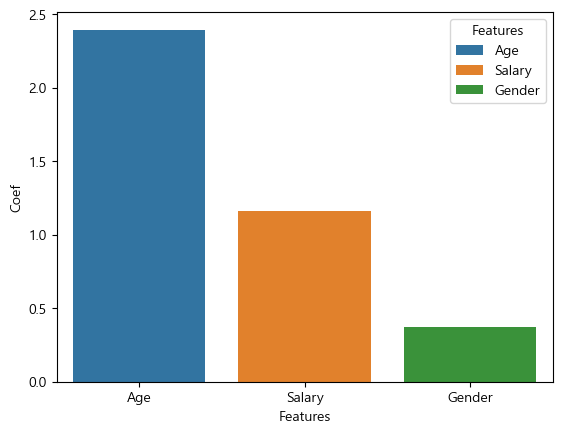

In [128]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features", legend=True)
plt.show()

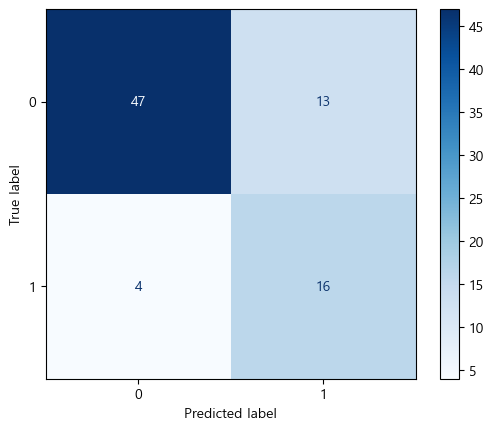

In [130]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.show()